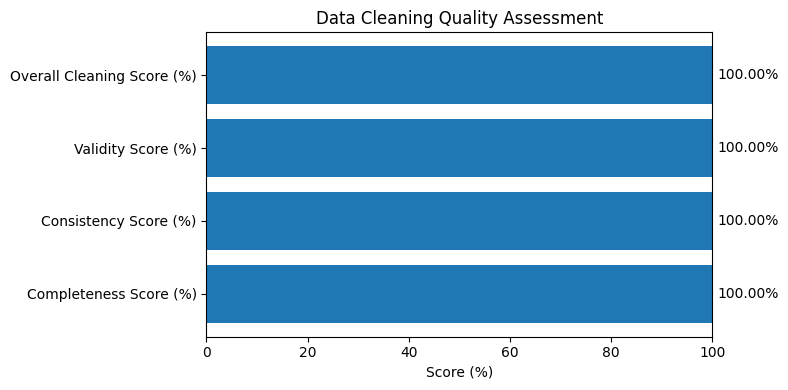

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv(r"Data\Processed\Processed.csv")
scores = {}

# -------------------------------------
# 1. COMPLETENESS SCORE
# -------------------------------------
# Checks missing values

total_values = df.shape[0] * df.shape[1]
missing_values = df.isnull().sum().sum()

completeness_score = (
    (total_values - missing_values) / total_values
) * 100

scores["Completeness Score (%)"] = round(completeness_score, 2)


# -------------------------------------
# 2. CONSISTENCY SCORE
# -------------------------------------
# Checks duplicate records

duplicate_count = df.duplicated().sum()

consistency_score = (
    (len(df) - duplicate_count) / len(df)
) * 100

scores["Consistency Score (%)"] = round(consistency_score, 2)


# -------------------------------------
# 3. VALIDITY SCORE
# -------------------------------------
# Checks whether values follow rules

validity_results = []


# Average validity score
if len(validity_results) > 0:
    validity_score = sum(validity_results) / len(validity_results)
else:
    validity_score = 100


scores["Validity Score (%)"] = round(validity_score, 2)


# -------------------------------------
# 4. OVERALL CLEANING SCORE
# -------------------------------------

overall_score = (
    completeness_score +
    consistency_score +
    validity_score
) / 3


scores["Overall Cleaning Score (%)"] = round(
    overall_score, 2
)


# -------------------------------------
# DISPLAY FINAL REPORT
# -------------------------------------

cleaning_report = pd.DataFrame(
    scores.items(),
    columns=[
        "Quality Measure",
        "Score (%)"
    ]
)


# -------------------------------------
# DATA CLEANING QUALITY CHART
# -------------------------------------

plt.figure(figsize=(8, 4))

bars = plt.barh(
    cleaning_report["Quality Measure"],
    cleaning_report["Score (%)"]
)

plt.xlim(0, 100)
plt.xlabel("Score (%)")
plt.title("Data Cleaning Quality Assessment")

# Add score labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}%",
        va="center"
    )

plt.tight_layout()

# Save high-quality image
plt.savefig(
    "Data_Cleaning_Quality_Assessment.png",
    dpi=300,
    bbox_inches="tight"
)


plt.savefig(
    os.path.join(
        os.getcwd(),
        "outputs/Eda/Data_Cleaning_Quality_Assessment.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
